In [5]:
using Optics_in_the_length_gauge
using BZpaths
using Bravais
using LinearAlgebra
using Brillouin
using CairoMakie, LaTeXStrings
include("model.jl")
include("wrapper.jl") 

sigma_abc_TaRh2B2_wrapper (generic function with 1 method)

In [29]:
using Pkg
Pkg.add(path="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")

    Updating git-repo `https://github.com/fernandopenaranda/Optics_in_the_length_gauge`
   Resolving package versions...
    Updating `~/Documents/Work/PostdocDonosti/Packages/Field_Induced_Hall_Effect/Project.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
    Updating `~/Documents/Work/PostdocDonosti/Packages/Field_Induced_Hall_Effect/Manifest.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
Precompiling project...
  ✓ Optics_in_the_length_gauge
  ✓ Field_Induced_Hall_Effect
  2 dependencies successfully precompiled in 7 seconds. 315 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new ve

In [12]:
import Pkg; Pkg.precompile()

Precompiling project...
  ✓ Field_Induced_Hall_Effect
  1 dependency successfully precompiled in 2 seconds. 316 already precompiled.
  1 dependency had warnings during precompilation:
┌ Field_Induced_Hall_Effect [f57a1fe4-d949-4368-b10e-a4b5a13ce036]
│  WARNING: Method definition kwcall(Any, typeof(Optics_in_the_length_gauge.integrand_quantum_contribution), Any, Any, Any, Any, Any, Any, Any, Any) in module Optics_in_the_length_gauge at /Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/5hBQJ/src/positional_shift.jl:51 overwritten at /Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/5hBQJ/src/positional_shift.jl:42.
│    ** incremental compilation may be fatally broken for this module **
│  
│  WARNING: Method definition hamiltonian_TaRh2B2(Any, Any, Any, Any, Any) in module Field_Induced_Hall_Effect at /Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/Field_Induced_Hall_Effect/src/model.jl:4 overwritten at /Users/fernandopenaranda/Docume

In [3]:
using CairoMakie, LaTeXStrings

## Init - BZ - Constants

In [9]:


a0 = 1#Å
c0 = 1
Rs = (a0 .* [1.0, 0, 0], a0 .* [-1/2, √3/2, 0], [0, 0.0, c0])  # Lattice vectors, can be 2d or 3d
high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A]    # Custom k-path over high symmetry momenta
sgnum = 144                                         # point group (144 = p3_1)
N = 200    

200

In [318]:
kp = irrfbz_path(sgnum, Rs)

KPath{3} (7 points, 3 paths, 13 points in paths):
 points: :M => [0.5, 0.0, 0.0]
         :A => [0.0, 0.0, 0.5]
         :H => [0.333333, 0.333333, 0.5]
         :K => [0.333333, 0.333333, 0.0]
         :Γ => [0.0, 0.0, 0.0]
         :L => [0.5, 0.0, 0.5]
         :H₂ => [0.333333, 0.333333, -0.5]
  paths: [:Γ, :M, :K, :Γ, :A, :L, :H, :A]
         [:L, :M]
         [:H, :K, :H₂]
  basis: [6.283185, 3.627599, -0.0]
         [0.0, 7.255197, 0.0]
         [0.0, -0.0, 6.283185]

In [337]:
Gs = dualbasis(Rs);
cell = wignerseitz(Gs) 

Cell{3} (8 faces, 12 vertices):
  verts: [0.666667, -0.333333, 0.5]
         [0.333333, 0.333333, 0.5]
         [0.333333, 0.333333, -0.5]
         [-0.333333, 0.666667, 0.5]
         [0.333333, -0.666667, 0.5]
         [0.666667, -0.333333, -0.5]
         [-0.333333, -0.333333, 0.5]
         [-0.666667, 0.333333, 0.5]
         [0.333333, -0.666667, -0.5]
         [-0.333333, -0.333333, -0.5]
         [-0.333333, 0.666667, -0.5]
         [-0.666667, 0.333333, -0.5]
  faces: [7, 8, 12, 10]
         [3, 2, 1, 6]
         [5, 9, 6, 1]
         [5, 7, 10, 9]
         [9, 10, 12, 11, 3, 6]
         [5, 1, 2, 4, 8, 7]
         [4, 11, 12, 8]
         [2, 3, 11, 4]
  basis: [6.283185, 3.627599, -0.0]
         [0.0, 7.255197, 0.0]
         [0.0, -0.0, 6.283185]

In [346]:
M = reduce(hcat, cell.verts)  
maxx = findmax(M[1,:][1])
maxy = findmin(M[1,:][1])

(0.6666666666666666, 1)

In [319]:
kpath(Rs, sgnum, N, high_sym_line);

## Bands

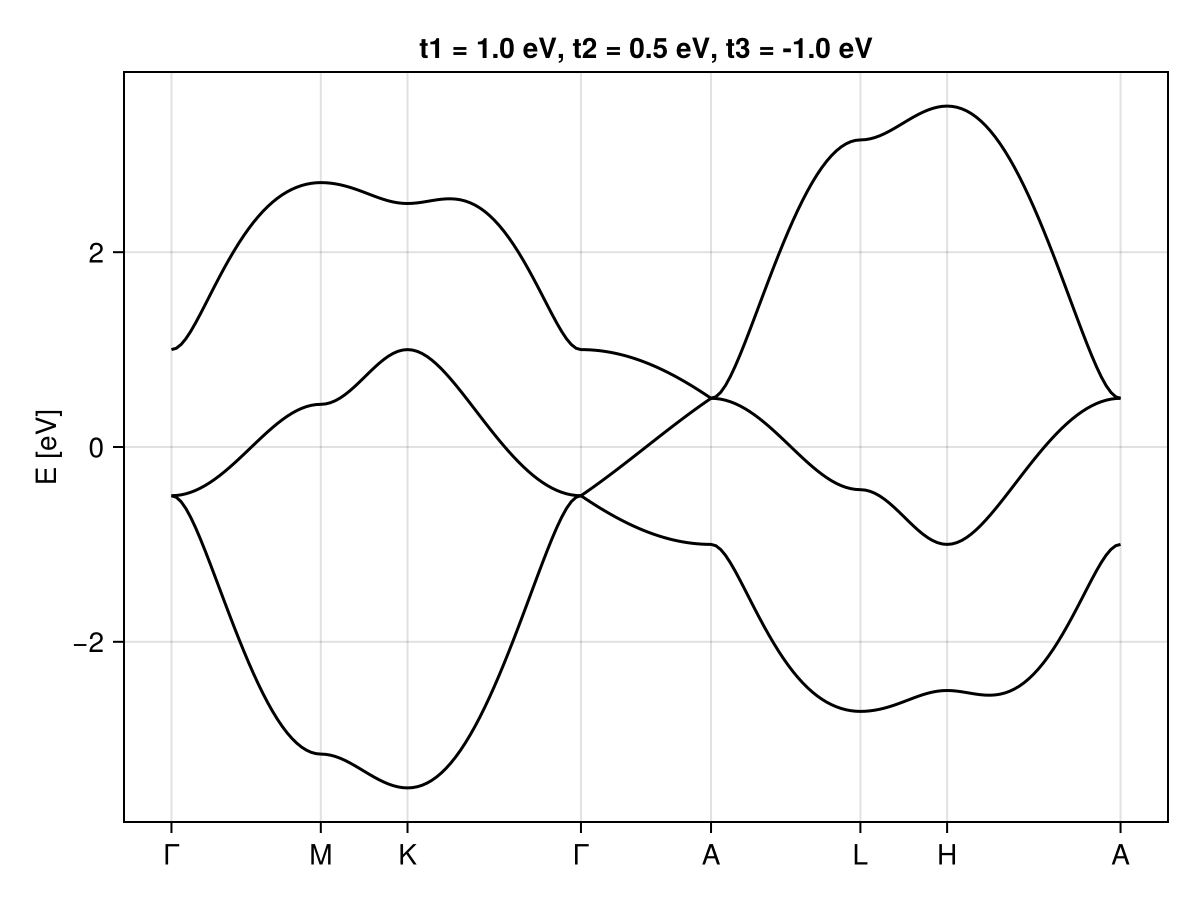

In [20]:
ts = [1,0.5,-1]
μ = 1.2
bands_TaRh2B2(0, ts)

In [ ]:
#= usage
1) Define the real space lattice vectors. They could be 3d or 2d
Rs = ([1.0, 0.0], [0, 1.0])

2) Specify the point group 1-17 for 2d 18 - 230 in 3d
sgnum = 10 # symmetry group number for the square 2d lattice

3) build the KPath object. 
kp = irrfbz_path(sgnum, Rs)

4) Note: kp will have custom k-paths along the high symmetry momenta 
coded in kp.paths. If you want custom paths within the BZ you can alter this struct by:
high_sym_path = [:Γ, :M, :X] # the vertices of the new path (symbols must be present in kp.paths)
new_kp = custom_path(high_sym_path, kp)

5) finally we interpolate evenly in these lines by:
N = 10 # number of kpoints
klist = cartesianize(interpolate(new_kp, N))
# Note: cartesianize is required to return klist in the cartesian basis and not in the bravais vectors lattice
=#

## Quantum correction to \sigma_ijk^(A,1)

In [3]:
p = sigma_abc_TaRh2B2_wrapper(:x,:y,:z);

Quantum_correction_σijk_antisym{var"#h#66"{Int64, Int64, Int64, Vector{Int64}}, var"#dh#70"{var"#dhz#69"{Int64, Int64, Vector{Int64}}, var"#dhy#68"{Int64, Int64, Vector{Int64}}, var"#dhx#67"{Int64, Int64, Vector{Int64}}}, var"#ddh#72"{var"#didjh#71"{Int64, Int64, Vector{Int64}}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  dirB: Symbol z
  h: h (function of type var"#h#66"{Int64, Int64, Int64, Vector{Int64}})
  nabla_h: dh (function of type var"#dh#70"{var"#dhz#69"{Int64, Int64, Vector{Int64}}, var"#dhy#68"{Int64, Int64, Vector{Int64}}, var"#dhx#67"{Int64, Int64, Vector{Int64}}})
  nabla_nabla_h: ddh (function of type var"#ddh#72"{var"#didjh#71"{Int64, Int64, Vector{Int64}}})
  τ: Float64 2.0e-13
  T: Float64 1.0
  computation: Transport_computation_3d_presets
  which_mm: Symbol orbital


In [6]:
σ_ijk_A1_qc =  quantum_contribution(p)

MethodError: MethodError: no method matching transpose(::var"#h#66"{Int64, Int64, Int64, Vector{Int64}})

Closest candidates are:
  transpose(!Matched::SparseArrays.AbstractSparseMatrixCSC)
   @ SparseArrays /Applications/Julia-1.9.app/Contents/Resources/julia/share/julia/stdlib/v1.9/SparseArrays/src/sparsematrix.jl:1359
  transpose(!Matched::Bidiagonal{var"#s972", V} where {var"#s972"<:Number, V<:AbstractVector{var"#s972"}})
   @ LinearAlgebra /Applications/Julia-1.9.app/Contents/Resources/julia/share/julia/stdlib/v1.9/LinearAlgebra/src/bidiag.jl:264
  transpose(!Matched::Bidiagonal)
   @ LinearAlgebra /Applications/Julia-1.9.app/Contents/Resources/julia/share/julia/stdlib/v1.9/LinearAlgebra/src/bidiag.jl:262
  ...


In [19]:
mats(q) = hamiltonian_TaRh2B2(μ,[2,2,2],q)

mats (generic function with 1 method)

In [20]:
mats([1,1,1])

3×3 Matrix{ComplexF64}:
     0.0+0.0im      4.73324+1.73656im  4.73324-1.73656im
 4.73324-1.73656im      0.0+0.0im      4.73324+1.73656im
 4.73324+1.73656im  4.73324-1.73656im      0.0+0.0im

In [21]:
hamiltonian_TaRh2B2(1, [1,1,1],[1,1,1])

3×3 Matrix{ComplexF64}:
    -1.0+0.0im      2.36662+0.86828im  2.36662-0.86828im
 2.36662-0.86828im     -1.0+0.0im      2.36662+0.86828im
 2.36662+0.86828im  2.36662-0.86828im     -1.0+0.0im

In [22]:
h([1,1,1])

3×3 Matrix{ComplexF64}:
    -1.0+0.0im      2.36662+0.86828im  2.36662-0.86828im
 2.36662-0.86828im     -1.0+0.0im      2.36662+0.86828im
 2.36662+0.86828im  2.36662-0.86828im     -1.0+0.0im

In [23]:


q = [0.,0.,1]
ϵs, ψs = eigen(Matrix(p.h(q)))   

Eigen{ComplexF64, Float64, Matrix{ComplexF64}, Vector{Float64}}
values:
3-element Vector{Float64}:
 -4.535024355398292
 -1.1347173224901184
  5.669741677888427
vectors:
3×3 Matrix{ComplexF64}:
 -0.288675+0.5im  -0.288675-0.5im  -0.57735-7.30103e-17im
 -0.288675-0.5im  -0.288675+0.5im  -0.57735+0.0im
   0.57735+0.0im    0.57735-0.0im  -0.57735-0.0im